In [1]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

In [57]:
m = 1
V1 = 3
sigma1 = 0.5
V2 = 5
sigma2 = 0.4
b = 1
gamma = 0.3
x0 = -0.5
v0 = 2

## **Part (a): Potential Landscape**

**Part (i)**

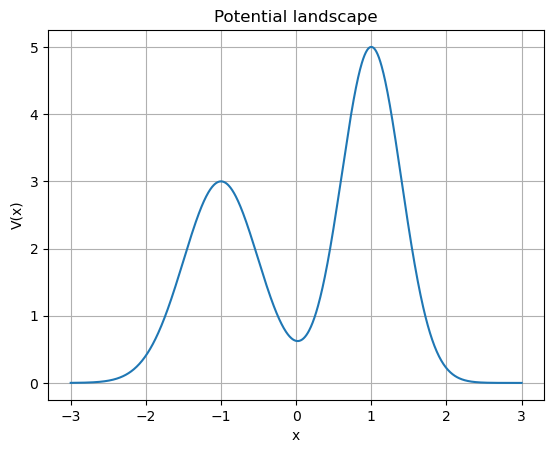

In [58]:
# Potential function
def V(x):
    return V1*np.exp(-(x+b)**2/(2*sigma1**2)) + V2*np.exp(-(x-b)**2/(2*sigma2**2))

# x-grid
xi, xf = -3, 3
N = 1000
xs = np.linspace(xi, xf, N)
# Potential
Vs = V(xs)

# Plotting
plt.plot(xs, Vs)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential landscape")

plt.grid()
plt.show()

**Left Gaussian hill:**

Height = 3

Position: $x = -1$

**Right Gaussian hill:**

Height = 5

Position: $x = 1$

Location of valley floor: $x = 0$


**Part (ii)**

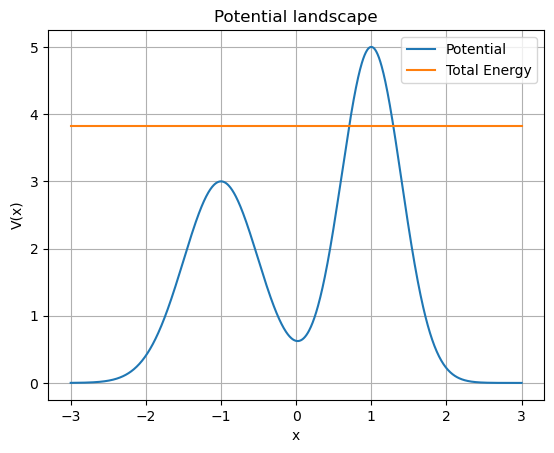

In [59]:
V0 = V(x0)
E0 = 1/2*m*v0**2 + V0

plt.plot(xs, Vs, label = "Potential")
plt.plot([xi, xf], [E0, E0], label = "Total Energy")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential landscape")

plt.legend()
plt.grid()
plt.show()

The classically accessible region is below the orange line for total energy. The particle is not able to surmount the right hill if there is no drag.

## **Part (b): Numerical Integration**

**Part (i)**

We consider:

$x = y[0] \\
v = y[1]
$

In [60]:
# RK4
def rk4(f1, x, y, h, gamma):
    k1 = h * f1(x, y, gamma)
    k2 = h * f1(x + h / 2, y + k1 / 2, gamma)
    k3 = h * f1(x + h / 2, y + k2 / 2, gamma)
    k4 = h * f1(x + h, y + k3, gamma)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h, gamma):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h, gamma)
    return ys

# dV/dx
def dV_dx(x):
    return -(V1*(x+b)/sigma1**2*np.exp(-(x+b)**2/(2*sigma1**2)) + V2*(x-b)/sigma2**2*np.exp(-(x-b)**2/(2*sigma2**2)))

# d/dt [x v]
def f1(t, y, gamma):
    return np.array([y[1], 1/m*(-dV_dx(y[0]) - gamma*y[1])])


Implementing RK4

In [ ]:
ti, tf = 0, 30
dt = 1e-3
Y0 = np.array([x0, v0])     # Initial conditions
N = int((tf - ti)/dt) + 1
ts = np.linspace(ti, tf, N)     # Time grid

Ys = caller(f1, Y0, N, ts, dt, gamma)

**Part (ii)**: Plotting

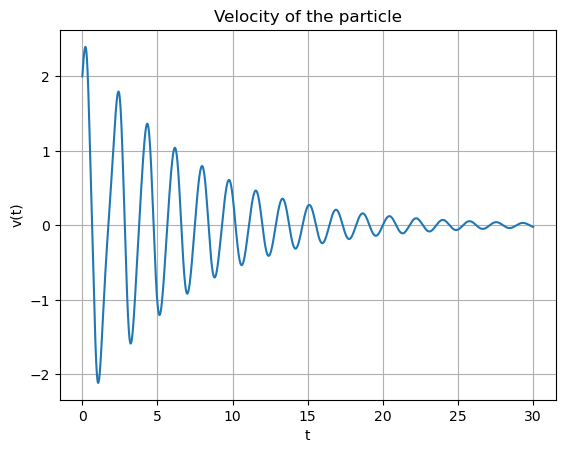

In [62]:
plt.plot(ts, Ys[:, 1])
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Velocity of the particle")

plt.grid()
plt.show()

In this problem, right is taken as positive and left as negative.

**Stage 1:**

$$\dot{v} = \frac{1}{m}\left[-\frac{dV}{dx} - \gamma v\right]$$

If acceleration = $\dot{v} > 0$, then:
$$-\frac{dV}{dx} > \gamma v$$

In the beginning, $v_0$ = 2 m/s, $x_0$ = 0.5 m and $\gamma = 0.3$.
$$-\frac{dV}{dx}(x_0) = 3.6 \\[10 pt]
\gamma v = 0.6 \\[10 pt]
\implies -\frac{dV}{dx} > \gamma v$$

Hence, acceleration > 0 $\implies$ velocity increases, as expected and as can be seen from the plot. This physically means that the drag force acting on the particle is less than the force that the potential acts on it to accelerate it. The particle descends into the valley from the left hill.

**Stage 2:**

The particle climbs up the right hill. In the process, its velocity decreases due to 2 factors:
1. Potential force acting in opposite direction.
2. Drag force acting in opposite direction.

As a result, velocity decreases and reaches 0 $\implies$ 1st turning point.

**Stage 3:**

The particle changes direction and starts descending from the right hill. Once at the valley, the particle has maximum velocity (-ve as it is towards the left). It starts ascending the left hill.

At every such stage, its maximum velocity keeps on decreasing (visible in the plot) due to the drag force it experiences. After some time, it almost reaches 0 due to energy dissipation and it oscillates near $x = 0 \implies$ stable equilibrium point.

In [31]:
-dV_dx(x0)

3.59775460013822

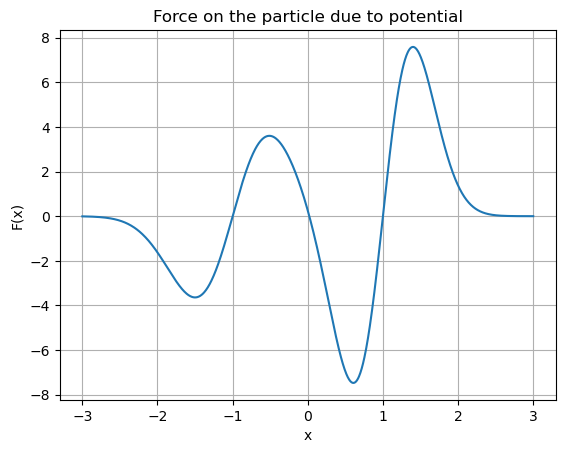

In [121]:
plt.plot(xs, -dV_dx(xs))
plt.xlabel("x")
plt.ylabel("F(x)")
plt.title("Force on the particle due to potential")
plt.grid()
plt.show()

**Part (iii)**: Phase Portrait

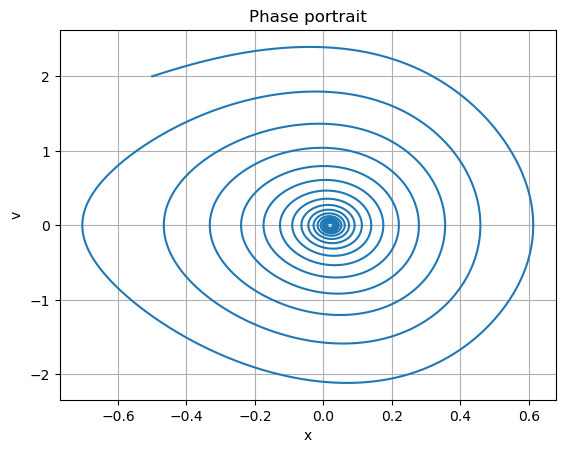

In [63]:
plt.plot(Ys[:, 0], Ys[:, 1])
plt.xlabel("x")
plt.ylabel("v")
plt.title("Phase portrait")
plt.grid()
plt.show()

The dissipative force $-\gamma v$ continuously dissipates energy from the system. Hence, the maximum velocity and maximum displacement decrease with time. Thus, the trajectory has inward-spiraling loops as the same path is never retraced again.

The fixed point at which the loop spirals is the point where:
$$\dot{x} = v = 0 \\[10 pt]
\dot{v} = 0 \\[10 pt]
\implies -\frac{dV}{dx} = \gamma v = 0$$

This is the point of stable equilibrium - the floor of the valley. The plot does not converge exactly at $x = 0$, since the potential is asymmetric and the simulation is run for a finite time. 

## **Part (c): Turning points on the right wall**

**Part (i):**

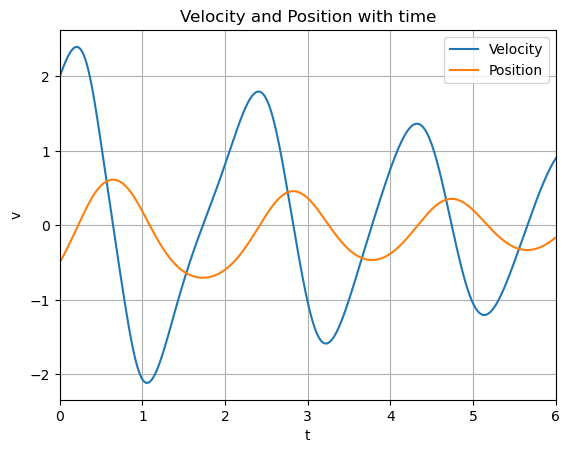

In [68]:
plt.plot(ts, Ys[:, 1], label = "Velocity")
plt.plot(ts, Ys[:, 0], label = "Position")
plt.xlabel("t")
plt.ylabel("v")
plt.title("Velocity and Position with time")
plt.xlim(0, 6)

plt.legend()
plt.grid()
plt.show()

As can be seen from the plot, the 3 bracketing intervals are:
1. $t_1 \in [0.5, 1]$
2. $t_2 \in [2.5, 3]$
3. $t_3 \in [4.5, 5]$

**Part (ii):**

Generating position and velocity functions from existing data through interpolation

In [97]:
from scipy.interpolate import interp1d

ys, vs = Ys[:, 0], Ys[:, 1]
v_func = interp1d(ts, vs)
y_func = interp1d(ts, ys)


Performing bisection through interpolated function

In [106]:
# Bisection function
def bisection1(f, left: float, right: float, eps: float, maxiter: int = 100):
  # Bad Interval
  if f(left)*f(right) > 0:
    print("Bad Interval")
    return None

  # If the roots are at the interval ends
  if abs(f(left)) < eps:
    return (left, 0)
  if abs(f(right)) < eps:
    return (right, 0)

  mid = (left + right)/2
  iter = 0
  # Loops runs until the function value is within threshold or maxiterations are not reached
  while abs(f(mid)) > eps and iter < maxiter:
    iter += 1
    # print(iter, f(mid))     # To print iteration and function value after each iteration

    if f(left)*f(mid) < 0:    # Root in between left and mid
      right = mid
    else:                     # Root in between mid and right
      left = mid

    mid = (left + right)/2

  # If maximum number of iterations are reached and root is not found
  if iter == maxiter and abs(f(mid)) > eps:
    print("Did not converge")
    return None

  # Else return root
  return (mid, iter)

# Bracketing intervals
t1b = [0.5, 1]
t2b = [2.5, 3]
t3b = [4.5, 5]
eps = 1e-6
maxiter = 100

# Finding time of turning points
t1, iter1 = bisection1(v_func, t1b[0], t1b[1], eps, maxiter)
t2, iter2 = bisection1(v_func, t2b[0], t2b[1], eps, maxiter)
t3, iter3 = bisection1(v_func, t3b[0], t3b[1], eps, maxiter)

# Printing data
print("No.  Time  Position")
print(f"1  {t1: 0.3f}  {y_func(t1): 0.4f}")
print(f"2  {t2: 0.3f}  {y_func(t2): 0.4f}")
print(f"3  {t3: 0.3f}  {y_func(t3): 0.4f}")

No.  Time  Position
1   0.644   0.6128
2   2.826   0.4585
3   4.741   0.3554


Performing bisection without interpolated function (accuracy can only be set till 0.01 in that case)

In [ ]:
# Bisection method
# def bisection2(ys, start: int, end: int, eps: float, maxiter: int = 100):
#   # Bad Interval
#   if ys[start]*ys[end] > 0:
#     print("Bad Interval")
#     return None

#   # If the roots are at the interval ends
#   if abs(ys[start]) < eps:
#     return (start, 0)
#   if abs(ys[end]) < eps:
#     return (end, 0)

#   mid = (start + end)//2
#   iter = 0

#   # Loops runs until the function value is within threshold or maxiterations are not reached
#   while abs(ys[mid]) > eps and iter < maxiter:
#     iter += 1
#     # print(iter, f(mid))     # To print iteration and function value after each iteration

#     if ys[start]*ys[mid] < 0:    # Root in between start and mid
#       end = mid
#     else:                     # Root in between mid and end
#       start = mid

#     mid = (start + end)//2

#   # If maximum number of iterations are reached and root is not found
#   if iter == maxiter and abs(ys[mid]) > eps:
#     print("Did not converge")
#     return None

#   # Else return root
#   return (mid, iter)

# # Bracketing intervals
# t1b = [0.5, 1]
# t2b = [2.5, 3]
# t3b = [4.5, 5]
# eps = 1e-2
# maxiter = 100

# # Starting and ending indices of bracketing intervals
# t1s, t1e = np.where(ts == t1b[0])[0][0], np.where(ts == t1b[1])[0][0]
# t2s, t2e = np.where(ts == t2b[0])[0][0], np.where(ts == t2b[1])[0][0]
# t3s, t3e = np.where(ts == t3b[0])[0][0], np.where(ts == t3b[1])[0][0]

# # Finding indices of time of turning points
# t1, iter1 = bisection2(vs, t1s, t1e, eps, maxiter)
# t2, iter2 = bisection2(vs, t2s, t2e, eps, maxiter)
# t3, iter3 = bisection2(vs, t3s, t3e, eps, maxiter)

# # Printing data
# print("No. Time  Position")
# print(f"1  {ts[t1]}  {ys[t1]: 0.4f}")
# print(f"2  {ts[t2]}  {ys[t2]: 0.4f}")
# print(f"3  {ts[t3]}  {ys[t3]: 0.4f}")

No. Time  Position
1  0.644   0.6128
2  2.827   0.4585
3  4.742   0.3554


**Part (iii):**

In [109]:
def E(t):
    return 1/2*m*v_func(t)**2 + V(y_func(t))

print("No. Energy")
print(f"1  {E(t1): 0.3f}")
print(f"2  {E(t2): 0.3f}")
print(f"3  {E(t3): 0.3f}")

No. Energy
1   3.146
2   2.042
3   1.441


The turning point positions on the right wall decrease with each successive bounce since the particle loses energy due to the drag force. Hence, it travels lesser distance in successive bounces.

**Part (iv):**

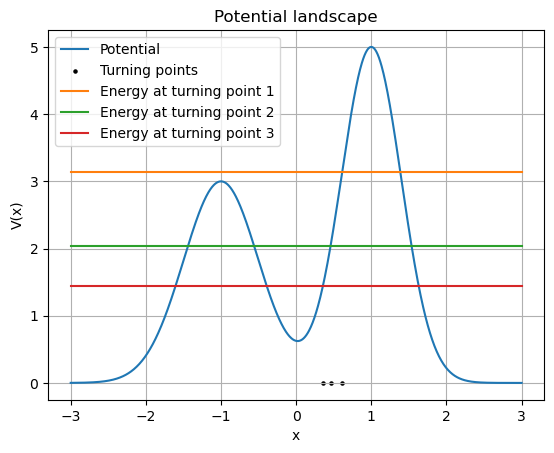

In [113]:
# Energy and position of turning points
y1, y2, y3 = y_func(t1), y_func(t2), y_func(t3)
E1, E2, E3 = E(t1), E(t2), E(t3)

# Plotting
plt.plot(xs, Vs, label = "Potential")
plt.scatter(y1, 0, color = "black", s = 5, label = "Turning points")
plt.scatter(y2, 0, color = "black", s = 5)
plt.scatter(y3, 0, color = "black", s = 5)
plt.plot([xi, xf], [E1, E1], label = "Energy at turning point 1")
plt.plot([xi, xf], [E2, E2], label = "Energy at turning point 2")
plt.plot([xi, xf], [E3, E3], label = "Energy at turning point 3")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential landscape")

plt.legend()
plt.grid()
plt.show()

As expected, the energies at successive turning points decrease monotonically, since energy is dissipated due to the drag force.

## **Part (d): Effect of drag**

**Part (i):**

Solving for different gamma

In [115]:
gamma0, gamma1 = 0, 0.6
Ys0 = caller(f1, Y0, N, ts, dt, gamma0)
Ys1 = caller(f1, Y0, N, ts, dt, gamma1)
vs0, vs1 = Ys0[:, 1], Ys1[:, 1]

Plotting

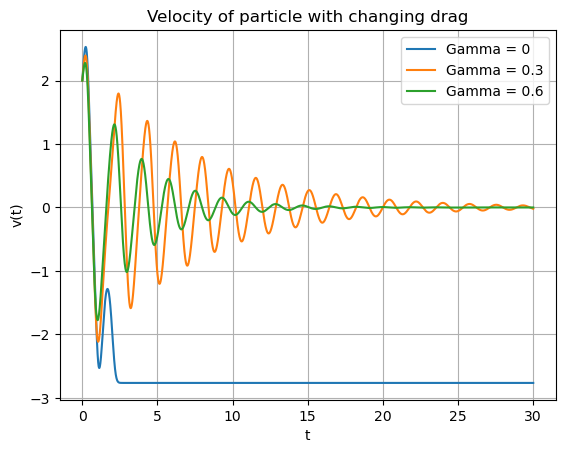

In [116]:
plt.plot(ts, vs0, label = f"Gamma = {gamma0}")
plt.plot(ts, vs, label = f"Gamma = {gamma}")
plt.plot(ts, vs1, label = f"Gamma = {gamma1}")
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title("Velocity of particle with changing drag")

plt.legend()
plt.grid()
plt.show()

**Part (ii):**

Phase portrait for $\gamma = 0$

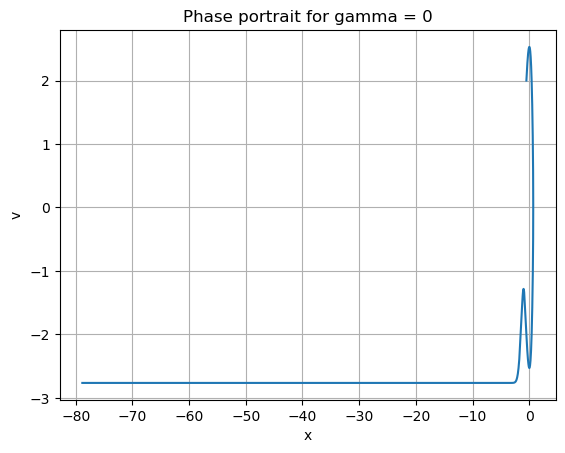

In [118]:
plt.plot(Ys0[:, 0], vs0)
plt.xlabel("x")
plt.ylabel("v")
plt.title("Phase portrait for gamma = 0")

plt.grid()
plt.show()

As can be seen from the velocity and phase portrait plot for $\gamma = 0$, the particle never settles. It attains a constant velocity and keeps on moving with that velocity forever.

This happens because when $\gamma = 0$, there is no drag force. The energy of the particle remains constant with time as there is no dissipation. Since the initial energy is higher than the height of the left hill, the particle climbs and crosses the left hill. After that, it keeps on moving to the left with a constant velocity (-ve as it moves left).